# Post-SMOTE Dataset Statistics
Generates basic statistics and histograms for the post-SMOTE training dataset.

--- Numerical Summaries ---
       person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  cb_person_cred_hist_length  credit_score
count   53530.000      53530.000       53530.000  53530.000      53530.000                   53530.000     53530.000
mean       26.852      69737.932           4.345   9729.354         11.628                       5.342       631.473
std         4.269      42208.712           4.262   6202.614          2.951                       2.972        46.356
min        20.000       8000.000           0.000    500.000          5.420                       2.000       390.000
25%        23.897      41640.354           1.000   5000.000          9.752                       3.000       603.000
50%        26.000      60813.657           3.000   8233.149         11.490                       4.000       638.000
75%        29.000      86281.860           7.000  13074.511         13.780                       7.000       665.000
max        49.000     778815.000    

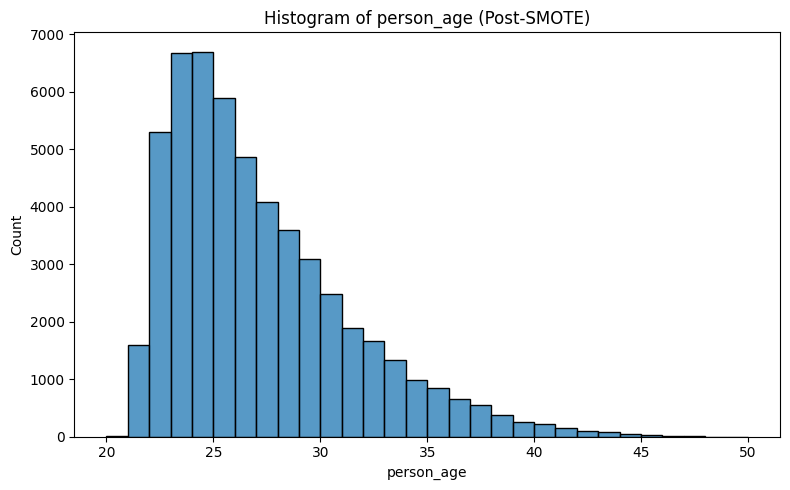

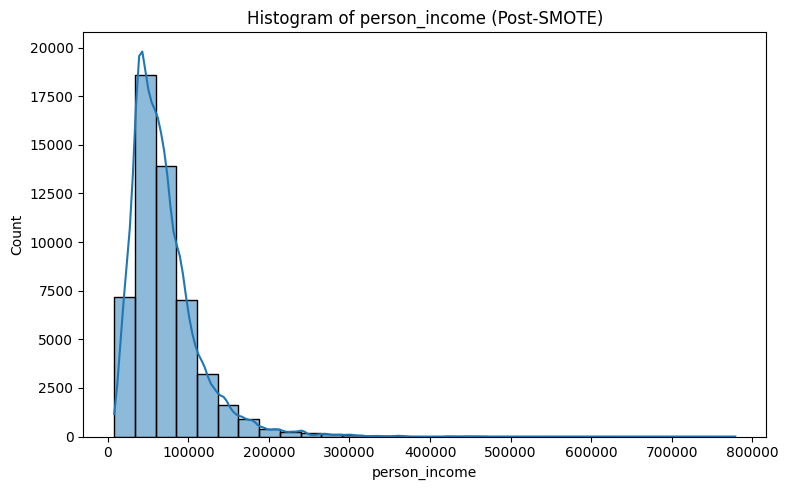

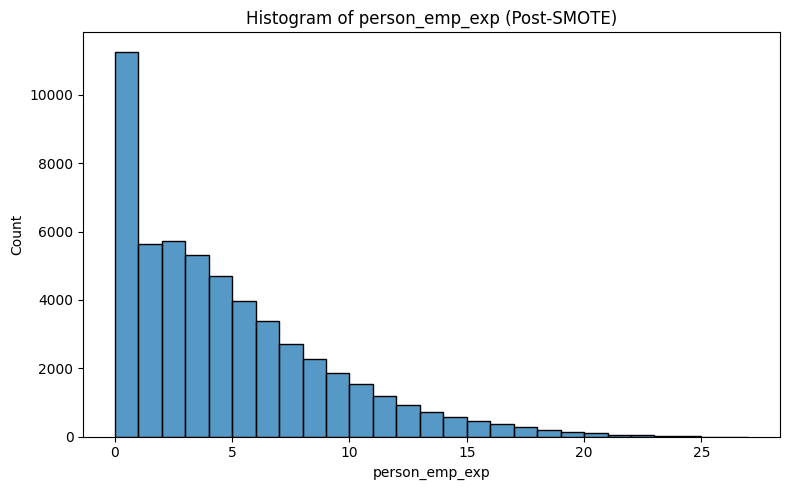

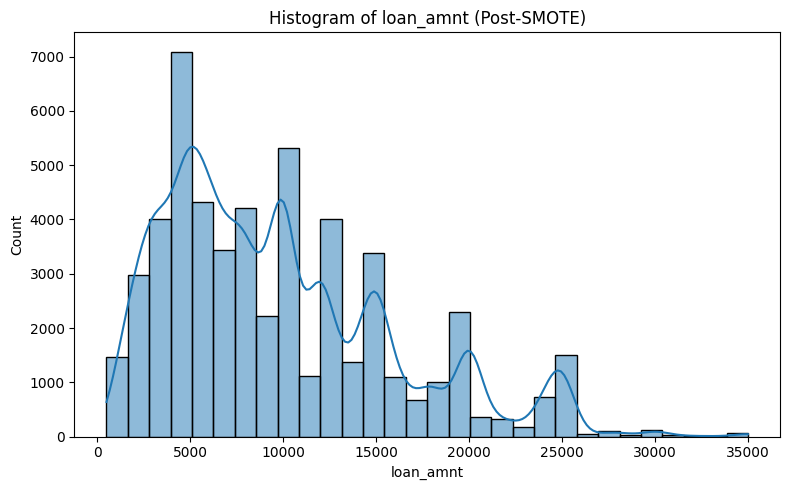

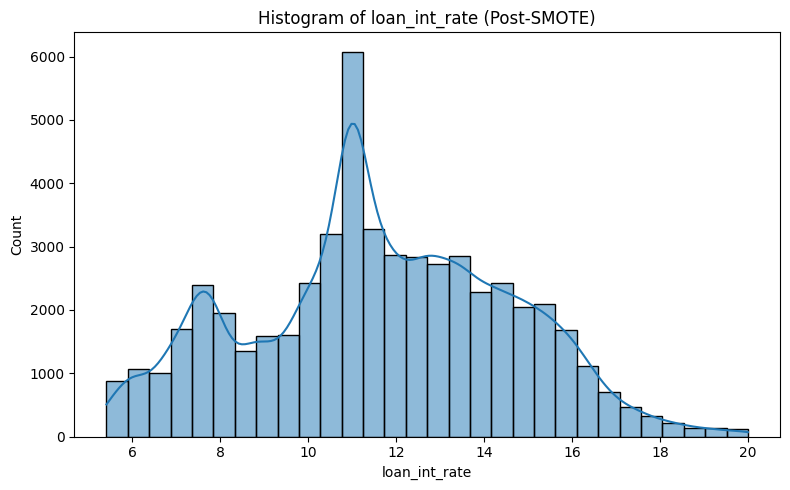

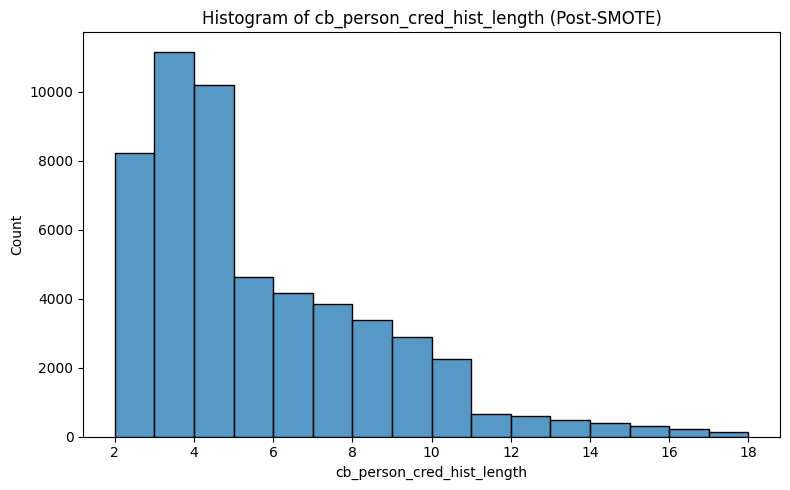

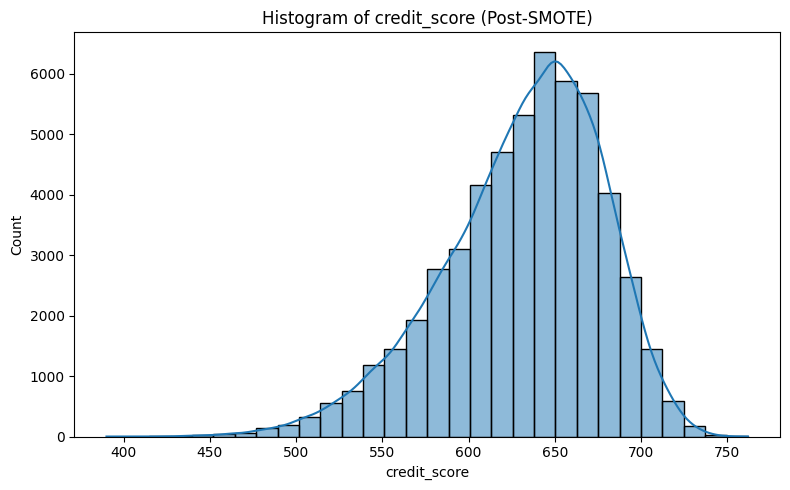

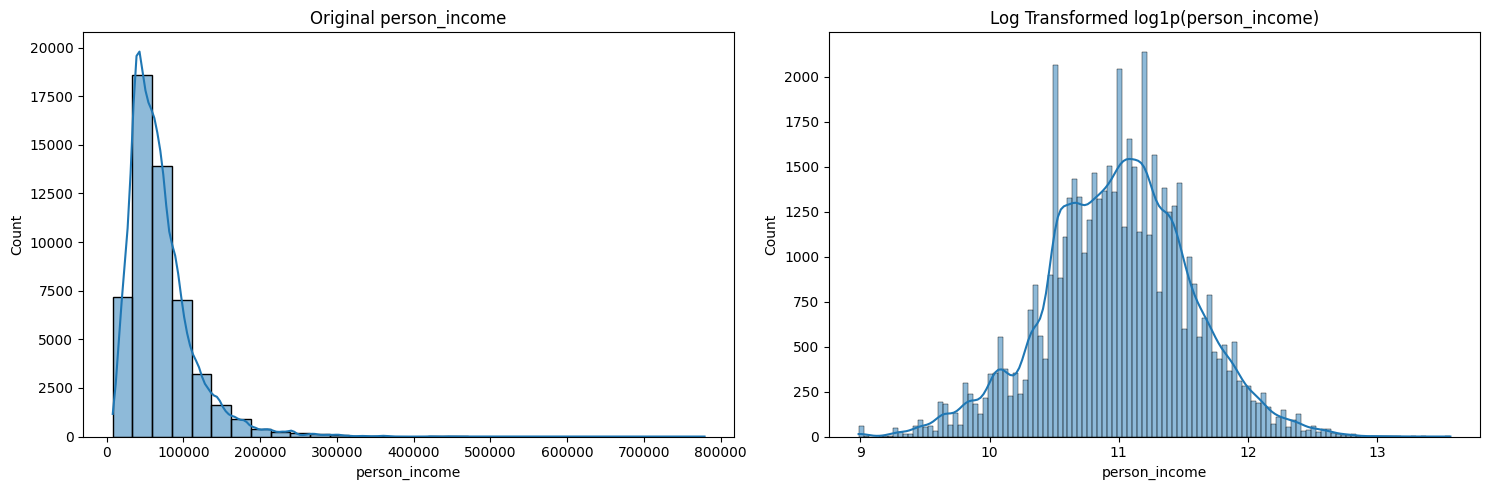

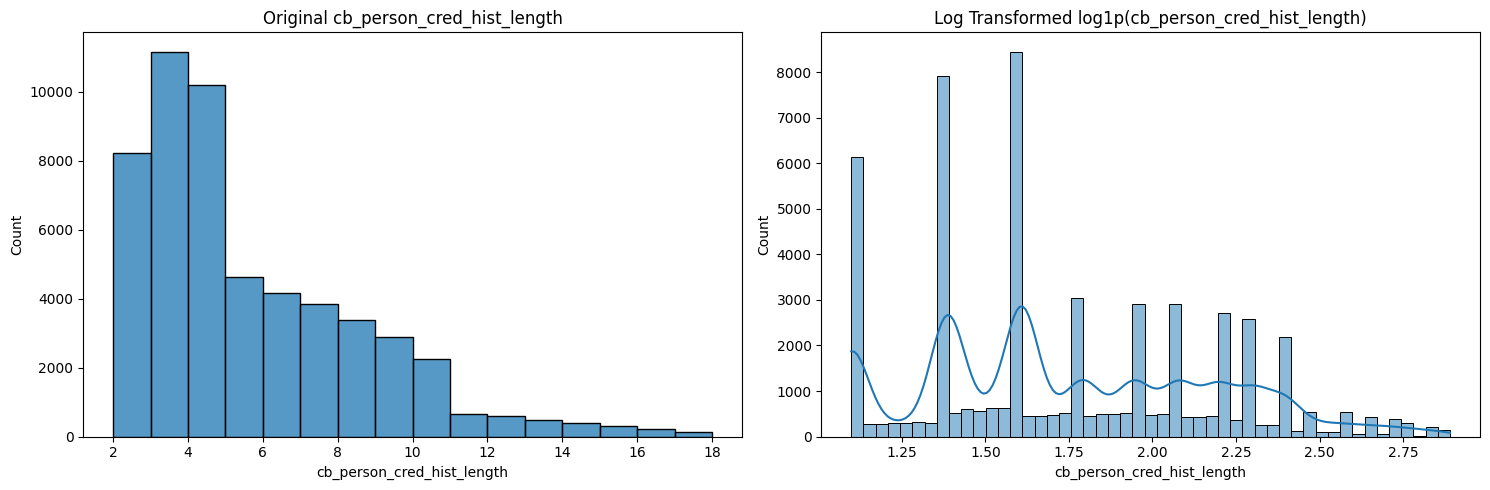

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the post-SMOTE data
data_path = "../data/pre-processed/loan_data_smoted_raw_train_4.csv"
df = pd.read_csv(data_path)

# Drop the loan_percent_income column
df = df.drop(columns=['loan_percent_income'], errors='ignore')

# Identify Categorical Columns
cat_cols = list(df.select_dtypes(include=['object', 'category']).columns)
if 'person_education' in df.columns:
    cat_cols.append('person_education')
if 'loan_status' in df.columns:
    cat_cols.append('loan_status')

# Print the Numerical Summaries (excluding categoricals)
print("--- Numerical Summaries ---")
num_df = df.drop(columns=[c for c in cat_cols if c in df.columns])
print(num_df.describe().round(3).to_string())

# Print the Categorical Counts
for col in cat_cols:
    if col in df.columns:
        print(f"\n--- {col} Counts ---")
        print(df[col].value_counts().to_string())

# Generate Histograms for all Numerical Features
num_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns if c not in cat_cols]
discrete_cols = ['person_age', 'cb_person_cred_hist_length', 'person_emp_exp']
for col in num_cols:
    plt.figure(figsize=(8, 5))
    
    # SMOTE created fractional values for Age and Credit History. 
    # We explicitly force bins to be 1-integer wide for these features.
    if col in discrete_cols:
        min_val = int(np.floor(df[col].min()))
        max_val = int(np.ceil(df[col].max()))
        bins = np.arange(min_val, max_val + 2)
        sns.histplot(df[col], kde=False, bins=bins)
    else:
        sns.histplot(df[col], kde=True, bins=30)
        
    plt.title(f"Histogram of {col} (Post-SMOTE)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Log Transform Comparisons
cols_to_log = ['person_income', 'cb_person_cred_hist_length']
for col in cols_to_log:
    if col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        # Original
        if col in discrete_cols:
            min_val = int(np.floor(df[col].min()))
            max_val = int(np.ceil(df[col].max()))
            bins = np.arange(min_val, max_val + 2)
            sns.histplot(df[col], kde=False, bins=bins, ax=axes[0])
        else:
            sns.histplot(df[col], kde=True, bins=30, ax=axes[0])
        axes[0].set_title(f"Original {col}")
        
        # Log transformed
        sns.histplot(np.log1p(df[col]), kde=True, ax=axes[1])
        axes[1].set_title(f"Log Transformed log1p({col})")
        
        plt.tight_layout()
        plt.show()
